In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('tmdb_5000_movies.csv')

# Display first few rows to understand the data
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [2]:
# Check basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Dataset shape: (4803, 20)

Column names:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Missing values:
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

Data types:
budget                    int64
genres                

In [3]:
# Data cleaning
# Remove rows with missing critical values
df_clean = df.dropna(subset=['budget', 'revenue', 'vote_average'])

# Remove movies with zero budget or zero revenue (not meaningful for investment analysis)
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0)]

# Calculate Return on Investment (ROI)
df_clean['roi'] = (df_clean['revenue'] - df_clean['budget']) / df_clean['budget']

# Extract release year from release_date
df_clean['release_year'] = pd.to_datetime(df_clean['release_date'], errors='coerce').dt.year

# Remove rows with invalid year
df_clean = df_clean.dropna(subset=['release_year'])
df_clean['release_year'] = df_clean['release_year'].astype(int)

print(f"Original dataset: {len(df)} rows")
print(f"After cleaning: {len(df_clean)} rows")

Original dataset: 4803 rows
After cleaning: 3229 rows


In [4]:
# Function to extract main genre from genres JSON string
def extract_main_genre(genres_str):
    try:
        # Convert string to list of dictionaries
        genres_list = ast.literal_eval(genres_str)
        if genres_list:
            return genres_list[0]['name']
        else:
            return 'Unknown'
    except:
        return 'Unknown'

# Apply the function to create main_genre column
df_clean['main_genre'] = df_clean['genres'].apply(extract_main_genre)

# Check the distribution of genres
df_clean['main_genre'].value_counts().head(15)

main_genre
Drama              747
Comedy             634
Action             588
Adventure          288
Horror             197
Crime              141
Thriller           118
Animation           99
Fantasy             93
Science Fiction     79
Romance             70
Family              38
Documentary         30
Mystery             27
Western             22
Name: count, dtype: int64

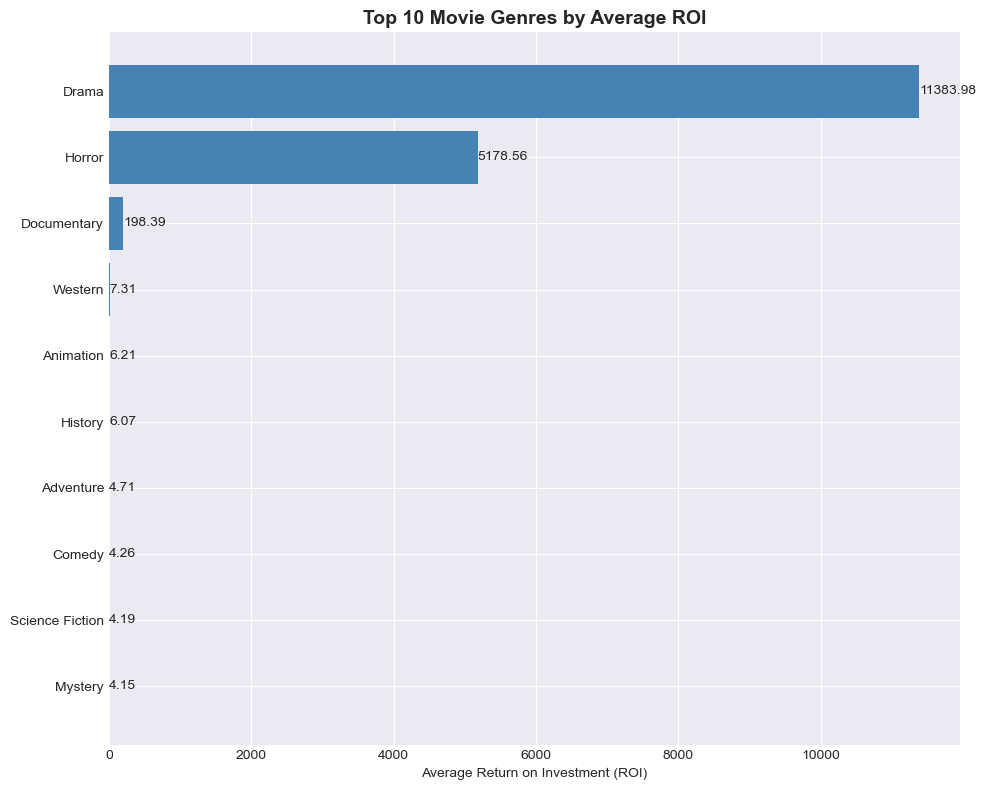


Most profitable genre: Drama
Average ROI for Drama: 11383.98


In [5]:
# Chart 1: Average ROI by Genre (Top 10)
genre_roi = df_clean.groupby('main_genre')['roi'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(genre_roi)), genre_roi.values, color='steelblue')
plt.yticks(range(len(genre_roi)), genre_roi.index)
plt.xlabel('Average Return on Investment (ROI)')
plt.title('Top 10 Movie Genres by Average ROI', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, v in enumerate(genre_roi.values):
    plt.text(v + 0.05, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

print("\nMost profitable genre:", genre_roi.index[0])
print(f"Average ROI for {genre_roi.index[0]}: {genre_roi.values[0]:.2f}")

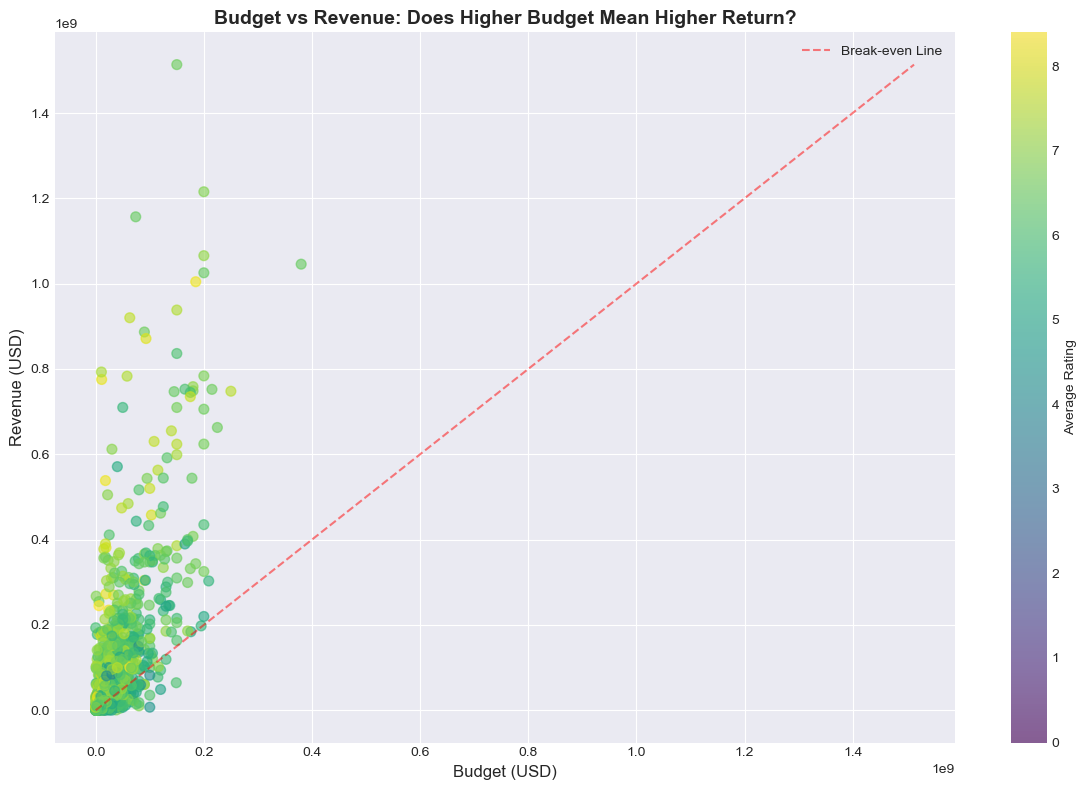

Correlation between budget and revenue: 0.705


In [6]:
# Chart 2: Budget vs Revenue Scatter Plot
plt.figure(figsize=(12, 8))

# Sample to avoid overcrowding (if dataset is large)
sample_df = df_clean.sample(min(1000, len(df_clean)))

scatter = plt.scatter(sample_df['budget'], sample_df['revenue'], 
                      c=sample_df['vote_average'], cmap='viridis', 
                      alpha=0.6, s=50)

plt.colorbar(scatter, label='Average Rating')
plt.xlabel('Budget (USD)', fontsize=12)
plt.ylabel('Revenue (USD)', fontsize=12)
plt.title('Budget vs Revenue: Does Higher Budget Mean Higher Return?', fontsize=14, fontweight='bold')

# Add a diagonal line (where revenue = budget, break-even point)
max_val = max(sample_df['budget'].max(), sample_df['revenue'].max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Break-even Line')

plt.legend()
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df_clean['budget'].corr(df_clean['revenue'])
print(f"Correlation between budget and revenue: {correlation:.3f}")

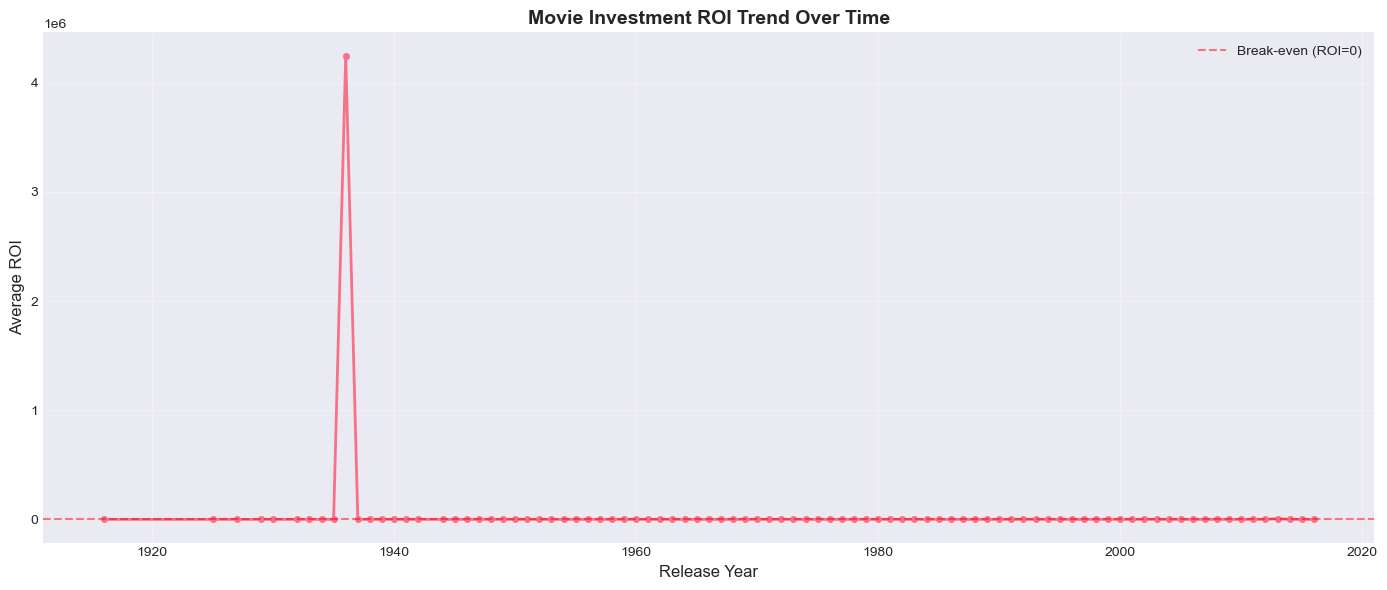

In [7]:
# Chart 3: ROI Trend Over Years
yearly_roi = df_clean.groupby('release_year')['roi'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(yearly_roi['release_year'], yearly_roi['roi'], marker='o', linewidth=2, markersize=4)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Average ROI', fontsize=12)
plt.title('Movie Investment ROI Trend Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Break-even (ROI=0)')
plt.legend()

plt.tight_layout()
plt.show()

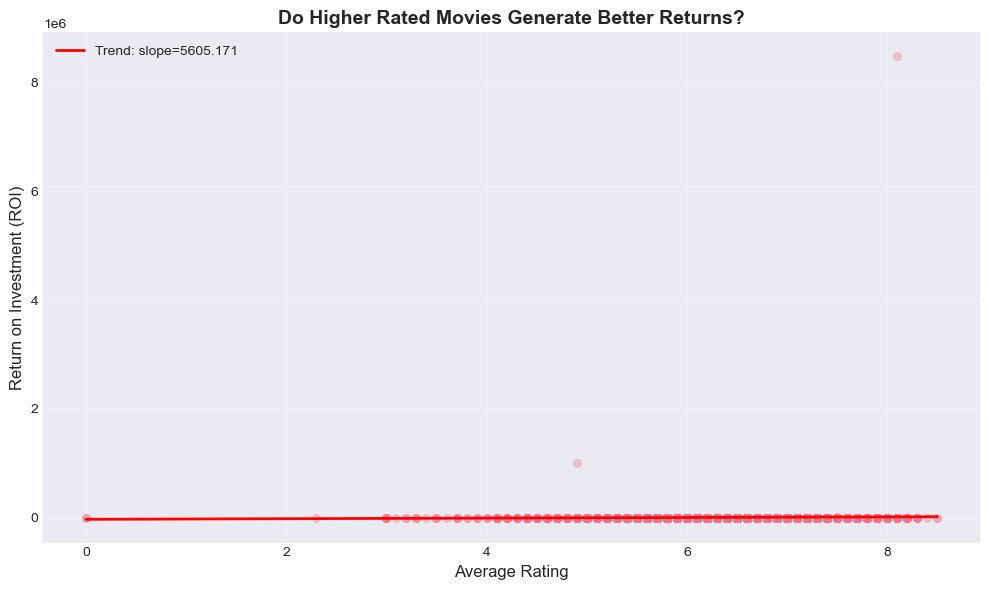

Correlation between rating and ROI: 0.033


In [8]:
# Chart 4: Rating vs ROI Relationship
plt.figure(figsize=(10, 6))

plt.scatter(df_clean['vote_average'], df_clean['roi'], alpha=0.3, s=30)

# Add trend line
z = np.polyfit(df_clean['vote_average'], df_clean['roi'], 1)
p = np.poly1d(z)
plt.plot(df_clean['vote_average'].sort_values(), 
         p(df_clean['vote_average'].sort_values()), 
         "r-", linewidth=2, label=f'Trend: slope={z[0]:.3f}')

plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Return on Investment (ROI)', fontsize=12)
plt.title('Do Higher Rated Movies Generate Better Returns?', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation between rating and ROI: {df_clean['vote_average'].corr(df_clean['roi']):.3f}")

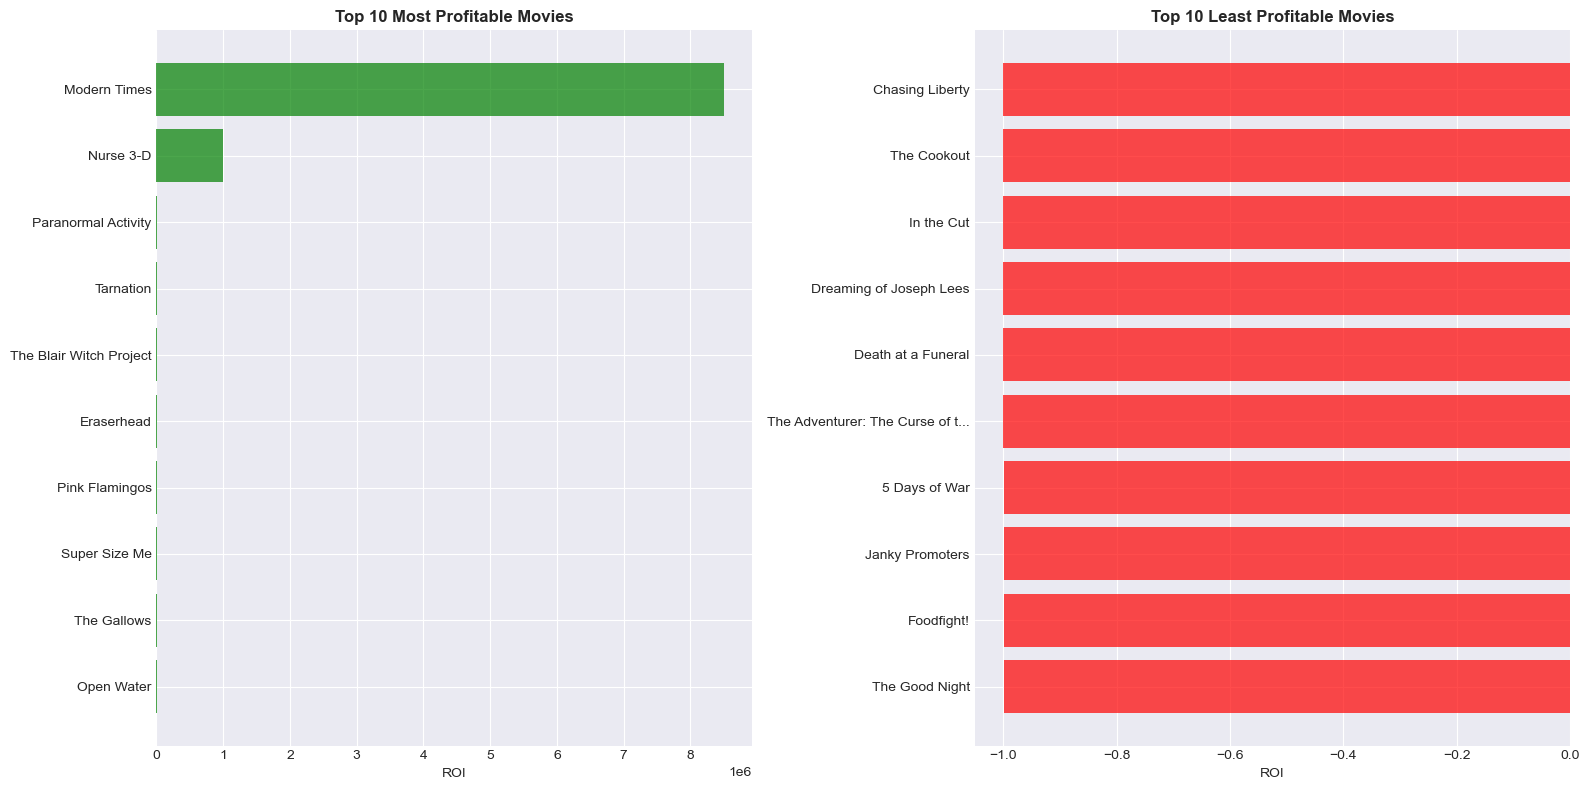

In [9]:
# Chart 5: Top 10 Most Profitable vs Least Profitable Movies

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Most profitable movies
top_roi = df_clean.nlargest(10, 'roi')[['title', 'roi', 'budget', 'revenue', 'main_genre']]
axes[0].barh(range(len(top_roi)), top_roi['roi'], color='green', alpha=0.7)
axes[0].set_yticks(range(len(top_roi)))
axes[0].set_yticklabels([f"{title[:30]}..." if len(title) > 30 else title for title in top_roi['title']])
axes[0].set_xlabel('ROI')
axes[0].set_title('Top 10 Most Profitable Movies', fontweight='bold')
axes[0].invert_yaxis()

# Least profitable movies (worst ROI)
bottom_roi = df_clean.nsmallest(10, 'roi')[['title', 'roi', 'budget', 'revenue', 'main_genre']]
axes[1].barh(range(len(bottom_roi)), bottom_roi['roi'], color='red', alpha=0.7)
axes[1].set_yticks(range(len(bottom_roi)))
axes[1].set_yticklabels([f"{title[:30]}..." if len(title) > 30 else title for title in bottom_roi['title']])
axes[1].set_xlabel('ROI')
axes[1].set_title('Top 10 Least Profitable Movies', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics for investment insights
print("=" * 60)
print("MOVIE INVESTMENT ANALYSIS - KEY INSIGHTS")
print("=" * 60)

print(f"\n1. Overall Statistics:")
print(f"   - Total movies analyzed: {len(df_clean)}")
print(f"   - Average ROI: {df_clean['roi'].mean():.2%}")
print(f"   - Median ROI: {df_clean['roi'].median():.2%}")
print(f"   - Success rate (ROI > 0): {(df_clean['roi'] > 0).mean():.1%}")

print(f"\n2. Best Genre for Investment: {genre_roi.index[0]}")
print(f"   - Average ROI: {genre_roi.values[0]:.2%}")
print(f"   - Number of {genre_roi.index[0]} movies: {len(df_clean[df_clean['main_genre'] == genre_roi.index[0]])}")

print(f"\n3. Risk Assessment:")
print(f"   - Movies that lost money (ROI < 0): {(df_clean['roi'] < 0).sum()} movies")
print(f"   - Percentage of losing investments: {(df_clean['roi'] < 0).mean():.1%}")

print(f"\n4. Rating Insight:")
print(f"   - High rating movies (>=7.5) average ROI: {df_clean[df_clean['vote_average'] >= 7.5]['roi'].mean():.2%}")
print(f"   - Low rating movies (<5.0) average ROI: {df_clean[df_clean['vote_average'] < 5.0]['roi'].mean():.2%}")

MOVIE INVESTMENT ANALYSIS - KEY INSIGHTS

1. Overall Statistics:
   - Total movies analyzed: 3229
   - Average ROI: 295382.24%
   - Median ROI: 130.04%
   - Success rate (ROI > 0): 75.5%

2. Best Genre for Investment: Drama
   - Average ROI: 1138398.15%
   - Number of Drama movies: 747

3. Risk Assessment:
   - Movies that lost money (ROI < 0): 789 movies
   - Percentage of losing investments: 24.4%

4. Rating Insight:
   - High rating movies (>=7.5) average ROI: 3210682.00%
   - Low rating movies (<5.0) average ROI: 521366.40%
